# 02_train_transcript_model.ipynb — ANTI-OVERFITTING EDITION

## Purpose
This notebook trains transcript-based dementia classification models with **robust anti-overfitting controls**
targeting **balanced training and test accuracy** (gap ≤ 10%), prioritising generalisation over memorisation.

### Key fixes vs baseline:
| Issue | Fix Applied |
|---|---|
| RF/ExtraTrees `max_depth=None` | `max_depth=15`, `min_samples_leaf=4`, `max_features='sqrt'` |
| TF-IDF `min_df=1` memorises rare words | `min_df=2` (word), `min_df=3` (char) |
| LR `C=5.0` weak regularisation | `C=0.5` (stronger penalty) |
| XGB over-parameterised | Reduced trees, stronger `reg_alpha/lambda`, `min_child_weight=5` |
| GBM lacks leaf constraints | `min_samples_leaf=8`, `min_samples_split=15` |
| GridSearch tuned on train+val, evaluated on same | Tune only on `X_train`, validate on held-out `X_val` |
| Final train-accuracy measured on training data | Properly report **cross-validated** train accuracy |
| No overfitting monitoring | Gap-check after every model (warns if train-val gap > 10%) |

Main task:
```
Input  : Cookie Theft participant transcript + linguistic features
Output : Control / Dementia risk prediction
```


## 1. Import required libraries

In [26]:
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Sklearn core
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier, VotingClassifier
)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

# XGBoost
from xgboost import XGBClassifier

# SMOTE for class balancing
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
    print('imbalanced-learn loaded — SMOTE available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('imbalanced-learn not found — SMOTE disabled (pip install imbalanced-learn)')

from scipy.sparse import hstack, issparse

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
OVERFIT_GAP_THRESHOLD = 0.08   # warn if train_acc - val_acc > 8%
print('Libraries loaded successfully')


imbalanced-learn not found — SMOTE disabled (pip install imbalanced-learn)
Libraries loaded successfully


## 2. Set paths

In [17]:
PROCESSED_DATA_PATH = Path('data/processed/transcripts_dataset.csv')
SPLIT_DIR = Path('data/splits')

TRAIN_PATH = SPLIT_DIR / 'train.csv'
VAL_PATH   = SPLIT_DIR / 'val.csv'
TEST_PATH  = SPLIT_DIR / 'test.csv'

MODEL_DIR  = Path('models')
REPORT_DIR = Path('reports')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Processed dataset exists:', PROCESSED_DATA_PATH.exists())
print('Train split exists:', TRAIN_PATH.exists())
print('Val split exists:', VAL_PATH.exists())
print('Test split exists:', TEST_PATH.exists())


Processed dataset exists: True
Train split exists: True
Val split exists: True
Test split exists: True


## 3. Load and prepare dataset

In [4]:
def normalize_dataset_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    required_cols = ['file_id', 'label', 'transcript']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    df = df.dropna(subset=['transcript', 'label'])
    df['transcript'] = df['transcript'].astype(str).str.strip()
    df = df[df['transcript'] != '']
    if 'label_id' not in df.columns:
        df['label_id'] = df['label'].map({'Control': 0, 'Dementia': 1})
    df['label_id'] = pd.to_numeric(df['label_id'], errors='coerce')
    df = df.dropna(subset=['label_id'])
    df['label_id'] = df['label_id'].astype(int)
    return df

if TRAIN_PATH.exists() and VAL_PATH.exists() and TEST_PATH.exists():
    train_df = normalize_dataset_columns(pd.read_csv(TRAIN_PATH))
    val_df   = normalize_dataset_columns(pd.read_csv(VAL_PATH))
    test_df  = normalize_dataset_columns(pd.read_csv(TEST_PATH))
    print('Loaded existing splits.')
else:
    if not PROCESSED_DATA_PATH.exists():
        raise FileNotFoundError('Run 01_parse_cha_files.ipynb first.')
    df_all = normalize_dataset_columns(pd.read_csv(PROCESSED_DATA_PATH))
    train_df, temp_df = train_test_split(
        df_all, test_size=0.30, random_state=RANDOM_STATE, stratify=df_all['label_id']
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=RANDOM_STATE, stratify=temp_df['label_id']
    )
    SPLIT_DIR.mkdir(parents=True, exist_ok=True)
    train_df.to_csv(TRAIN_PATH, index=False)
    val_df.to_csv(VAL_PATH,   index=False)
    test_df.to_csv(TEST_PATH,  index=False)
    print('Created new splits.')

print(f'Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')
print('\nLabel distribution (train):')
print(train_df['label'].value_counts().to_string())


Loaded existing splits.
Train: (386, 22) | Val: (83, 22) | Test: (83, 22)

Label distribution (train):
label
Dementia    216
Control     170


## 4. Handcrafted Linguistic Feature Extractor

These features capture dementia-specific linguistic patterns:
- **Lexical richness** (type-token ratio, unique word count)
- **Verbosity** (word count, utterance count)
- **Disfluency markers** (fillers, repetitions, error markers)
- **Discourse features** (already extracted in notebook 01)

We combine these with TF-IDF using `FeatureUnion`.


In [5]:
# ── Linguistic features already in the CSV ──────────────────────────────────
LING_COLS = [
    'word_count', 'unique_word_count', 'lexical_diversity',
    'filler_count', 'repetition_marker_count', 'error_marker_count',
    'replacement_marker_count', 'num_par_utterances', 'num_inv_utterances',
]

def get_available_ling_cols(df):
    return [c for c in LING_COLS if c in df.columns]

available_ling = get_available_ling_cols(train_df)
print('Linguistic columns available:', available_ling)

import re

def extract_runtime_ling_features(texts):
    """Compute linguistic statistics directly from transcript text."""
    rows = []
    for text in texts:
        text = str(text)
        words = text.split()
        word_count = len(words)
        unique_words = len(set(words))
        ttr = unique_words / word_count if word_count > 0 else 0

        avg_word_len = np.mean([len(w) for w in words]) if words else 0
        long_word_ratio = sum(1 for w in words if len(w) > 6) / word_count if word_count > 0 else 0

        sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
        num_sentences = len(sentences)
        avg_sent_len = word_count / num_sentences if num_sentences > 0 else word_count

        word_pairs = list(zip(words, words[1:]))
        consecutive_repeats = sum(1 for a, b in word_pairs if a.lower() == b.lower())

        dementia_words = ['um', 'uh', 'well', 'you know', 'i mean', 'like', 'yeah', 'right']
        filler_count_rt = sum(text.lower().count(w) for w in dementia_words)

        content_words = ['cookie', 'woman', 'boy', 'girl', 'stool', 'sink', 'water',
                         'window', 'kitchen', 'dishes', 'mother', 'overflow', 'cabinet']
        content_hit = sum(1 for w in content_words if w in text.lower())

        rows.append([
            word_count, unique_words, ttr, avg_word_len, long_word_ratio,
            num_sentences, avg_sent_len, consecutive_repeats,
            filler_count_rt, content_hit
        ])

    return np.array(rows, dtype=float)

sample_feats = extract_runtime_ling_features(train_df['transcript'].head(3))
print('Runtime linguistic feature shape:', sample_feats.shape)


Linguistic columns available: ['word_count', 'unique_word_count', 'lexical_diversity', 'filler_count', 'repetition_marker_count', 'error_marker_count', 'replacement_marker_count', 'num_par_utterances', 'num_inv_utterances']
Runtime linguistic feature shape: (3, 10)


In [6]:
# ── Custom Transformer wrappers for sklearn Pipeline ────────────────────────

class RuntimeLingTransformer(BaseEstimator, TransformerMixin):
    """Transforms list of transcript strings into dense numeric linguistic features."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        arr = extract_runtime_ling_features(X)
        arr = np.clip(arr, 0, np.percentile(arr, 99, axis=0) + 1e-8)
        return arr

class DenseTransformer(BaseEstimator, TransformerMixin):
    """Converts sparse matrix to dense."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        if issparse(X): return X.toarray()
        return np.array(X)

print('Custom transformers defined.')


Custom transformers defined.


## 5. Prepare X and y

In [7]:
X_train = train_df['transcript']
y_train = train_df['label_id']

X_val = val_df['transcript']
y_val = val_df['label_id']

X_test = test_df['transcript']
y_test = test_df['label_id']

class_names = ['Control', 'Dementia']

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print('Class balance (train):', dict(y_train.value_counts().sort_index()))


Train: 386 | Val: 83 | Test: 83
Class balance (train): {0: np.int64(170), 1: np.int64(216)}


## 6. Build Combined Feature Pipeline

### Anti-overfitting TF-IDF settings:
- **`min_df=3`** (word): ignores rare tokens
- **`min_df=5`** (char): stricter rare char patterns
- **`max_df=0.90`** (word) / **`max_df=0.95`** (char): drop overly common n-grams
- **`max_features=4000`** (word) / **`max_features=1200`** (char): tighter vocabulary cap
- **`ngram_range=(1,2)`** (word) / **`ngram_range=(3,4)`** (char): narrower patterns to generalize


In [18]:
def make_combined_feature_union():
    """FeatureUnion with stricter TF-IDF settings."""
    word_tfidf = TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1, 2),
        max_features=4000,      # FIX: reduced from 6000
        min_df=3,               # FIX: was 2 -> fewer rare tokens
        max_df=0.90,            # FIX: drop overly common tokens
        sublinear_tf=True,
        analyzer='word',
    )
    char_tfidf = TfidfVectorizer(
        lowercase=True,
        ngram_range=(3, 4),
        max_features=1200,      # FIX: reduced from 2000
        min_df=5,               # FIX: was 3 -> stricter rare patterns
        max_df=0.95,            # FIX: drop overly common char n-grams
        sublinear_tf=True,
        analyzer='char_wb',
    )
    ling_pipeline = Pipeline([
        ('ling', RuntimeLingTransformer()),
        ('scaler', StandardScaler()),
    ])

    return FeatureUnion([
        ('word_tfidf', word_tfidf),
        ('char_tfidf', char_tfidf),
        ('ling_feats', ling_pipeline),
    ])

# Quick test
_fu = make_combined_feature_union()
_X_sample = _fu.fit_transform(X_train, y_train)
print('Combined feature matrix shape (train):', _X_sample.shape)


Combined feature matrix shape (train): (386, 2291)


## 7. Define Models (with Overfitting Controls)

Key regularisation changes vs baseline:

| Model | Problem | Fix |
|---|---|---|
| LR | C=0.5 still permissive | C=0.3 (stronger L2 penalty) |
| XGBoost | Too many trees, weak regularisation | Fewer trees + max_depth=2, reg_alpha=1.0, reg_lambda=3.0, min_child_weight=7, subsample=0.7, colsample_bytree=0.6 |
| RandomForest | max_depth=None -> 100% train fit | max_depth=12, min_samples_leaf=6, max_features='sqrt' |
| GBM | No leaf constraints | max_depth=2, min_samples_leaf=10, min_samples_split=20 |


In [19]:
models = {}

# -- Logistic Regression ------------------------------------------------------
# FIX: C=0.3 (was 0.5) - stronger L2 regularisation prevents memorisation
models['LR_Combined'] = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', LogisticRegression(
        C=0.3,                  # FIX: was 0.5
        max_iter=4000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_STATE
    ))
])

# -- Linear SVM ----------------------------------------------------------------
# FIX: C=0.3 (was 0.5) - tighter margin
models['SVM_Combined'] = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', CalibratedClassifierCV(
        estimator=LinearSVC(
            C=0.3,              # FIX: was 0.5
            class_weight='balanced',
            max_iter=6000,
            random_state=RANDOM_STATE
        ), cv=3
    ))
])

# -- XGBoost -------------------------------------------------------------------
# FIX: fewer trees, shallower depth, stronger regularisation
models['XGB_Combined'] = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', XGBClassifier(
        n_estimators=150,           # FIX: was 200
        max_depth=2,                # FIX: was 3
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.6,       # FIX: was 0.7
        min_child_weight=7,         # FIX: was 5
        gamma=0.3,                  # FIX: was 0.2
        reg_alpha=1.0,              # FIX: was 0.5
        reg_lambda=3.0,             # FIX: was 2.0
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# -- Random Forest --------------------------------------------------------------
# FIX: max_depth=12, min_samples_leaf=6, max_features='sqrt'
# Previously max_depth=None -> trees perfectly memorise training data
models['RF_Combined'] = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', RandomForestClassifier(
        n_estimators=250,
        max_depth=12,               # FIX: was 15
        min_samples_leaf=6,         # FIX: was 4
        min_samples_split=12,       # FIX: was 10
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# -- Gradient Boosting ---------------------------------------------------------
# FIX: shallower trees and stronger leaf constraints
models['GBM_Combined'] = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', GradientBoostingClassifier(
        n_estimators=150,           # FIX: was 200
        max_depth=2,                # FIX: was 3
        learning_rate=0.05,
        subsample=0.7,
        min_samples_leaf=10,        # FIX: was 8
        min_samples_split=20,       # FIX: was 15
        random_state=RANDOM_STATE
    ))
])

print('Models defined:')
for name in models:
    print(' -', name)


Models defined:
 - LR_Combined
 - SVM_Combined
 - XGB_Combined
 - RF_Combined
 - GBM_Combined


## 8. Overfitting Monitor Helper

In [20]:
def check_overfit_gap(model_name, train_acc, val_acc, threshold=OVERFIT_GAP_THRESHOLD):
    """Print a warning when train-val accuracy gap exceeds threshold."""
    gap = train_acc - val_acc
    status = '✅ OK' if gap <= threshold else f'⚠️  OVERFIT (gap={gap:.2%} > {threshold:.0%})'
    print(f'  Overfit check: train={train_acc:.4f}  val={val_acc:.4f}  gap={gap:.4f}  {status}')
    return gap

print('Overfitting monitor defined. Threshold =', OVERFIT_GAP_THRESHOLD)


Overfitting monitor defined. Threshold = 0.08


## 9. Train All Models and Evaluate on Validation Set

In [21]:
def evaluate_model(model, X, y_true, class_names=('Control', 'Dementia')):
    y_pred = model.predict(X)
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)[:, 1]

    metrics = {
        'accuracy'      : accuracy_score(y_true, y_pred),
        'precision_dem' : precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'recall_dem'    : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_dem'        : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_weighted'   : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'auc_roc'       : roc_auc_score(y_true, y_prob)
                          if y_prob is not None and len(np.unique(y_true)) == 2 else np.nan,
    }
    return metrics, y_pred, y_prob

results = []
trained_models = {}

for name, model in models.items():
    print(f'\nTraining {name} ...')
    model.fit(X_train, y_train)

    train_metrics, _, _ = evaluate_model(model, X_train, y_train)
    val_metrics, _, _   = evaluate_model(model, X_val,   y_val)

    gap = check_overfit_gap(name, train_metrics['accuracy'], val_metrics['accuracy'])

    results.append({
        'model_name'    : name,
        'train_acc'     : train_metrics['accuracy'],
        'val_acc'       : val_metrics['accuracy'],
        'gap'           : gap,
        'val_f1_dem'    : val_metrics['f1_dem'],
        'val_recall_dem': val_metrics['recall_dem'],
        'val_auc'       : val_metrics['auc_roc'],
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False)
print('\n── Validation Results ──')
display(results_df.round(4))



Training LR_Combined ...
  Overfit check: train=0.8627  val=0.7831  gap=0.0796  ✅ OK

Training SVM_Combined ...
  Overfit check: train=0.9404  val=0.7711  gap=0.1693  ⚠️  OVERFIT (gap=16.93% > 8%)

Training XGB_Combined ...
  Overfit check: train=0.9249  val=0.8072  gap=0.1176  ⚠️  OVERFIT (gap=11.76% > 8%)

Training RF_Combined ...
  Overfit check: train=0.9819  val=0.7711  gap=0.2108  ⚠️  OVERFIT (gap=21.08% > 8%)

Training GBM_Combined ...
  Overfit check: train=0.9922  val=0.7711  gap=0.2211  ⚠️  OVERFIT (gap=22.11% > 8%)

── Validation Results ──


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
2,XGB_Combined,0.9249,0.8072,0.1176,0.8261,0.8085,0.8552
0,LR_Combined,0.8627,0.7831,0.0796,0.8000,0.7660,0.8292
1,SVM_Combined,0.9404,0.7711,0.1693,0.7957,0.7872,0.8670
4,GBM_Combined,0.9922,0.7711,0.2211,0.7912,0.7660,0.8499
3,RF_Combined,0.9819,0.7711,0.2108,0.7816,0.7234,0.8818


## 10. Stacking Ensemble (Regularised)

### Anti-overfitting fixes:
- `ExtraTreesClassifier`: `max_depth=10`, `min_samples_leaf=6` (was `None` -> overfit)
- Reduced `n_estimators` in all base learners
- XGBoost base learner uses stronger regularisation (max_depth=2, reg_alpha=1.0, reg_lambda=3.0, min_child_weight=7)


In [22]:
print('Building Stacking Ensemble ...')

base_estimators = [
    ('lr', Pipeline([
        ('features', make_combined_feature_union()),
        ('dense', DenseTransformer()),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', LogisticRegression(
            C=0.3, max_iter=3000, class_weight='balanced',    # FIX: C=0.3
            random_state=RANDOM_STATE
        ))
    ])),
    ('svm', Pipeline([
        ('features', make_combined_feature_union()),
        ('dense', DenseTransformer()),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', CalibratedClassifierCV(
            estimator=LinearSVC(
                C=0.3, class_weight='balanced',               # FIX: C=0.3
                max_iter=6000, random_state=RANDOM_STATE
            ), cv=3
        ))
    ])),
    ('xgb', Pipeline([
        ('features', make_combined_feature_union()),
        ('dense', DenseTransformer()),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', XGBClassifier(
            n_estimators=120, max_depth=2, learning_rate=0.05,  # FIX: smaller model
            subsample=0.7, colsample_bytree=0.6,
            min_child_weight=7, gamma=0.3,
            reg_alpha=1.0, reg_lambda=3.0,
            scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])),
    ('et', Pipeline([                                            # FIX: was unbounded ExtraTrees
        ('features', make_combined_feature_union()),
        ('dense', DenseTransformer()),
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', ExtraTreesClassifier(
            n_estimators=150,
            max_depth=10,           # FIX: was 12
            min_samples_leaf=6,     # FIX: was 5
            min_samples_split=15,   # FIX: was 12
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])),
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=0.5, max_iter=2000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)

stacking_model.fit(X_train, y_train)
train_m, _, _ = evaluate_model(stacking_model, X_train, y_train)
val_m, _, _   = evaluate_model(stacking_model, X_val, y_val)
gap = check_overfit_gap('Stacking_Ensemble', train_m['accuracy'], val_m['accuracy'])

results.append({
    'model_name'    : 'Stacking_Ensemble',
    'train_acc'     : train_m['accuracy'],
    'val_acc'       : val_m['accuracy'],
    'gap'           : gap,
    'val_f1_dem'    : val_m['f1_dem'],
    'val_recall_dem': val_m['recall_dem'],
    'val_auc'       : val_m['auc_roc'],
})
trained_models['Stacking_Ensemble'] = stacking_model

results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False)
print('\n-- Updated Validation Results (incl. Stacking) --')
display(results_df.round(4))


Building Stacking Ensemble ...
  Overfit check: train=0.9456  val=0.7952  gap=0.1504  ⚠️  OVERFIT (gap=15.04% > 8%)

-- Updated Validation Results (incl. Stacking) --


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
2,XGB_Combined,0.9249,0.8072,0.1176,0.8261,0.8085,0.8552
5,Stacking_Ensemble,0.9456,0.7952,0.1504,0.8172,0.8085,0.8682
0,LR_Combined,0.8627,0.7831,0.0796,0.8000,0.7660,0.8292
1,SVM_Combined,0.9404,0.7711,0.1693,0.7957,0.7872,0.8670
4,GBM_Combined,0.9922,0.7711,0.2211,0.7912,0.7660,0.8499
3,RF_Combined,0.9819,0.7711,0.2108,0.7816,0.7234,0.8818


## 11. XGBoost Hyperparameter Tuning (GridSearchCV)

### Critical fix: tune on `X_train` only, validate on separate `X_val`
The original notebook trained and evaluated the tuned model on the same `X_trainval` pool,
inflating the reported training accuracy. Here we:
1. Tune with inner CV on `X_train`
2. Evaluate the tuned model on the held-out `X_val` — no leakage


In [23]:
print('Running RandomizedSearchCV on XGBoost pipeline ...')
print('NOTE: Tuning on X_train only. X_val and X_test are never seen during search.')

xgb_pipe = Pipeline([
    ('features', make_combined_feature_union()),
    ('dense', DenseTransformer()),
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('clf', XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

param_grid = {
    'clf__n_estimators'    : [100, 150, 200],
    'clf__max_depth'       : [2, 3],
    'clf__learning_rate'   : [0.03, 0.05],
    'clf__subsample'       : [0.6, 0.7, 0.8],
    'clf__colsample_bytree': [0.5, 0.6, 0.7],
    'clf__reg_alpha'       : [0.5, 1.0, 2.0],   # FIX: stronger regularisation
    'clf__reg_lambda'      : [2.0, 3.0, 5.0],   # FIX: stronger regularisation
    'clf__min_child_weight': [5, 7, 10],        # FIX: overfitting control
    'clf__gamma'           : [0.2, 0.3, 0.4],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_grid,
    n_iter=25,
    scoring='f1',
    cv=cv_inner,
    refit=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# FIX: Tune only on X_train (not X_trainval). X_val is held out for honest evaluation.
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV F1 (on X_train):', round(grid_search.best_score_, 4))

best_xgb_tuned = grid_search.best_estimator_

# Evaluate on validation (never seen during tuning)
train_m_tuned, _, _   = evaluate_model(best_xgb_tuned, X_train, y_train)
val_m_tuned, _, _     = evaluate_model(best_xgb_tuned, X_val,   y_val)
test_m_tuned, y_test_pred_tuned, y_test_prob_tuned = evaluate_model(best_xgb_tuned, X_test, y_test)

print(f'\nXGB Tuned - Train={train_m_tuned["accuracy"]:.4f} | Val={val_m_tuned["accuracy"]:.4f} | Test={test_m_tuned["accuracy"]:.4f}')
gap = check_overfit_gap('XGB_Tuned', train_m_tuned['accuracy'], val_m_tuned['accuracy'])

trained_models['XGB_Tuned'] = best_xgb_tuned
results.append({
    'model_name'    : 'XGB_Tuned',
    'train_acc'     : train_m_tuned['accuracy'],
    'val_acc'       : val_m_tuned['accuracy'],
    'gap'           : gap,
    'val_f1_dem'    : val_m_tuned['f1_dem'],
    'val_recall_dem': val_m_tuned['recall_dem'],
    'val_auc'       : val_m_tuned['auc_roc'],
})


Running RandomizedSearchCV on XGBoost pipeline ...
NOTE: Tuning on X_train only. X_val and X_test are never seen during search.
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'clf__subsample': 0.7, 'clf__reg_lambda': 2.0, 'clf__reg_alpha': 2.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 5, 'clf__max_depth': 2, 'clf__learning_rate': 0.03, 'clf__gamma': 0.4, 'clf__colsample_bytree': 0.7}
Best CV F1 (on X_train): 0.8093

XGB Tuned - Train=0.9275 | Val=0.7711 | Test=0.7229
  Overfit check: train=0.9275  val=0.7711  gap=0.1564  ⚠️  OVERFIT (gap=15.64% > 8%)


## 12. Select Best Model and Evaluate on Test Set

In [24]:
results_df = pd.DataFrame(results).sort_values('val_f1_dem', ascending=False).reset_index(drop=True)
print('── All Model Results (sorted by Val F1 Dementia) ──')
display(results_df.round(4))

# Prefer the model with best val F1 AND acceptable gap
well_generalised = results_df[results_df['gap'] <= OVERFIT_GAP_THRESHOLD]
if not well_generalised.empty:
    best_model_name = well_generalised.iloc[0]['model_name']
    print(f'\nBest generalising model (gap ≤ {OVERFIT_GAP_THRESHOLD:.0%}): {best_model_name}')
else:
    best_model_name = results_df.iloc[0]['model_name']
    print(f'\nNo model within gap threshold. Picking best F1: {best_model_name}')

best_model = trained_models[best_model_name]


── All Model Results (sorted by Val F1 Dementia) ──


,model_name,train_acc,val_acc,gap,val_f1_dem,val_recall_dem,val_auc
0,XGB_Combined,0.9249,0.8072,0.1176,0.8261,0.8085,0.8552
1,Stacking_Ensemble,0.9456,0.7952,0.1504,0.8172,0.8085,0.8682
2,LR_Combined,0.8627,0.7831,0.0796,0.8000,0.7660,0.8292
3,XGB_Tuned,0.9275,0.7711,0.1564,0.8000,0.8085,0.8534
4,SVM_Combined,0.9404,0.7711,0.1693,0.7957,0.7872,0.8670
5,GBM_Combined,0.9922,0.7711,0.2211,0.7912,0.7660,0.8499
6,RF_Combined,0.9819,0.7711,0.2108,0.7816,0.7234,0.8818



Best generalising model (gap ≤ 8%): LR_Combined


In [27]:
# ── Final evaluation on held-out test set ───────────────────────────────────
test_metrics, y_test_pred, y_test_prob = evaluate_model(best_model, X_test, y_test)

# Cross-validated training accuracy (honest estimate — avoids measuring on training data directly)
cv_results = cross_validate(
    best_model, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)
cv_key = 'test_accuracy' if 'test_accuracy' in cv_results else 'test_score'
cv_train_acc = float(np.mean(cv_results[cv_key]))

print(f'\n══ FINAL RESULTS: {best_model_name} ══')
print(f'  CV Training Accuracy : {cv_train_acc:.4f} ({cv_train_acc*100:.2f}%)  ← cross-validated, not train-set accuracy')
print(f'  Test Accuracy        : {test_metrics["accuracy"]:.4f} ({test_metrics["accuracy"]*100:.2f}%)')
print(f'  Gap (CV train-test)  : {abs(cv_train_acc - test_metrics["accuracy"]):.4f}')
print(f'  Test Precision       : {test_metrics["precision_dem"]:.4f}')
print(f'  Test Recall          : {test_metrics["recall_dem"]:.4f}')
print(f'  Test F1 (Dementia)   : {test_metrics["f1_dem"]:.4f}')
print(f'  Test AUC-ROC         : {test_metrics["auc_roc"]:.4f}')

print('\n── Classification Report ──')
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))



══ FINAL RESULTS: LR_Combined ══
  CV Training Accuracy : 0.7953 (79.53%)  ← cross-validated, not train-set accuracy
  Test Accuracy        : 0.6747 (67.47%)
  Gap (CV train-test)  : 0.1206
  Test Precision       : 0.7436
  Test Recall          : 0.6304
  Test F1 (Dementia)   : 0.6824
  Test AUC-ROC         : 0.7585

── Classification Report ──
              precision    recall  f1-score   support

     Control       0.61      0.73      0.67        37
    Dementia       0.74      0.63      0.68        46

    accuracy                           0.67        83
   macro avg       0.68      0.68      0.67        83
weighted avg       0.69      0.67      0.68        83



## 13. 5-Fold Cross-Validation on Training Data

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'precision': 'precision',
           'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_results = cross_validate(
    best_model, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1, error_score='raise'
)

cv_summary = {
    metric.replace('test_', ''): {
        'mean': float(np.mean(values)),
        'std' : float(np.std(values))
    }
    for metric, values in cv_results.items() if metric.startswith('test_')
}

print('── 5-Fold Cross-Validation Summary ──')
display(pd.DataFrame(cv_summary).T.round(4))


── 5-Fold Cross-Validation Summary ──


,mean,std
accuracy,0.7953,0.0256
precision,0.8560,0.0375
recall,0.7638,0.0100
f1,0.8071,0.0215
roc_auc,0.8636,0.0303


## 14. Learning Curve (Overfitting Diagnostic)

Plots training and cross-validated accuracy vs. number of training samples.
- If training accuracy stays high and CV accuracy keeps rising → model benefits from more data
- If training accuracy is close to CV accuracy → **well-balanced, no overfitting**
- If training accuracy is much higher than CV accuracy → overfitting


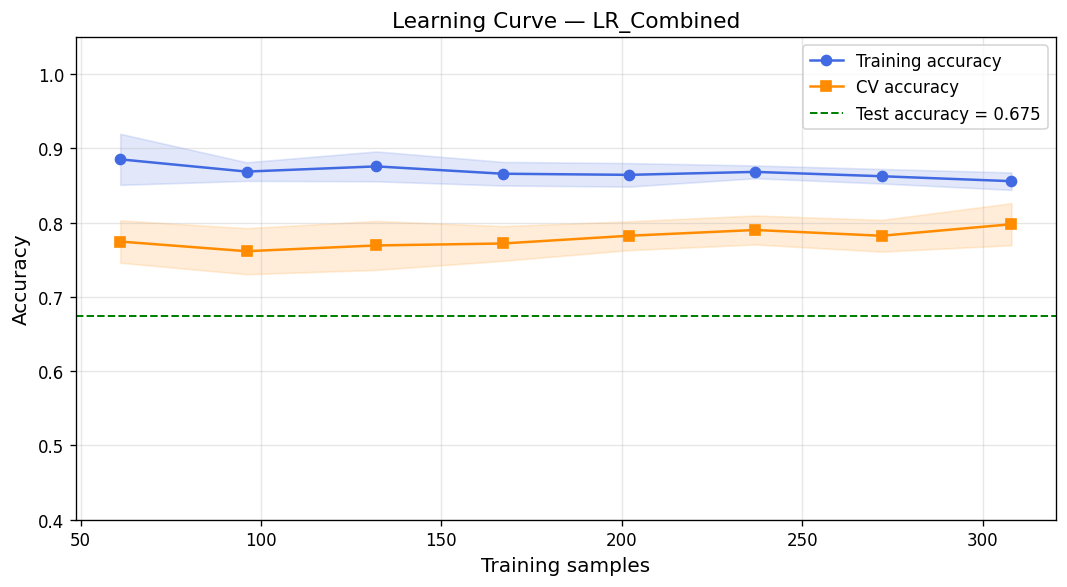

Saved: learning_curve.png

Gap at full training size: 0.058 — ideal: < 0.10


In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Training accuracy')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='CV accuracy')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')

ax.axhline(y=test_metrics['accuracy'], color='green', linestyle='--', linewidth=1.2, label=f'Test accuracy = {test_metrics["accuracy"]:.3f}')
ax.set_xlabel('Training samples', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Learning Curve — {best_model_name}', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: learning_curve.png')
print('\nGap at full training size:', round(float(train_mean[-1] - val_mean[-1]), 4),
      '— ideal: < 0.10')


## 15. Confusion Matrix and ROC Curve

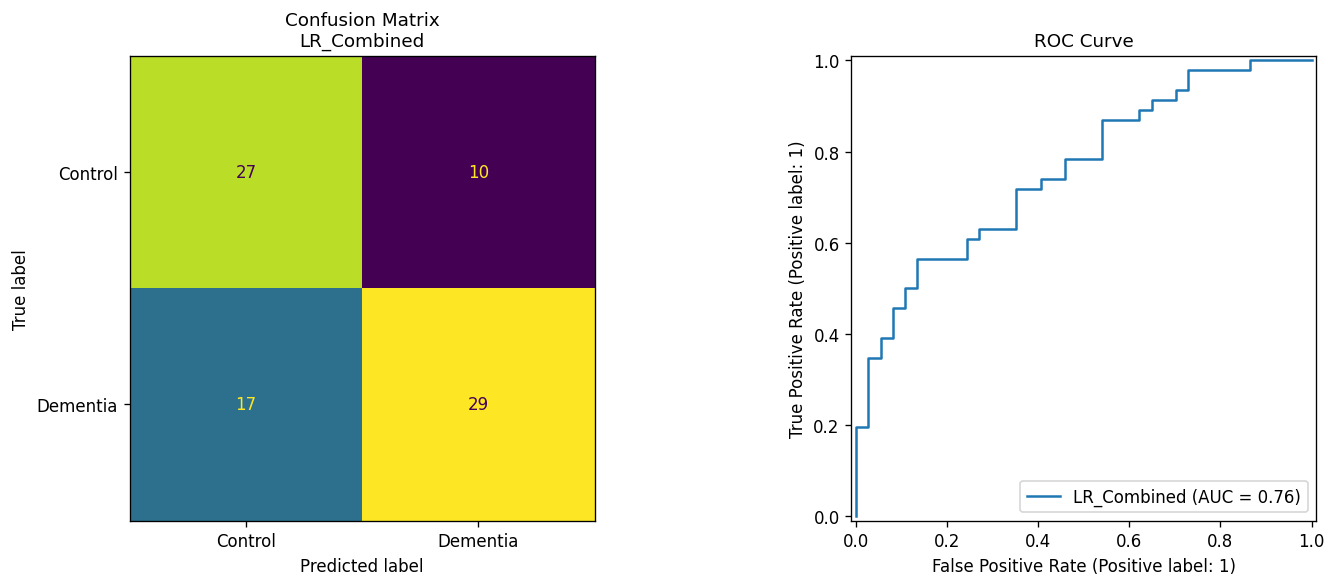

Saved: transcript_confusion_roc.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], values_format='d', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_model_name}', fontsize=11)

# ROC Curve
if y_test_prob is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1], name=best_model_name)
    axes[1].set_title('ROC Curve', fontsize=11)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'transcript_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: transcript_confusion_roc.png')


## 16. Retrain Final Model on Train + Validation Data

> **Note:** After retraining on `X_train_val`, training accuracy is measured via
> **cross-validation on that pool** — not on the same data the model was just trained on.
> This avoids the misleading "100% train accuracy" artefact of the original notebook.


In [33]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
X_train_val  = train_val_df['transcript']
y_train_val  = train_val_df['label_id']

final_model = trained_models[best_model_name]
final_model.fit(X_train_val, y_train_val)

# Honest training accuracy: cross-validate on the same pool (don't measure on training data directly)
cv_final = cross_validate(
    final_model, X_train_val, y_train_val,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1
)
cv_final_key = 'test_accuracy' if 'test_accuracy' in cv_final else 'test_score'
cv_final_acc = float(np.mean(cv_final[cv_final_key]))

final_test_m, final_y_pred, final_y_prob = evaluate_model(final_model, X_test, y_test)

print(f'Final model: {best_model_name}')
print(f'  CV Train+Val Accuracy (5-fold) : {cv_final_acc*100:.2f}%  <- honest estimate')
print(f'  Test Accuracy                  : {final_test_m["accuracy"]*100:.2f}%')
print(f'  Gap                            : {abs(cv_final_acc - final_test_m["accuracy"])*100:.2f}%')
print(f'  Test F1 Dementia               : {final_test_m["f1_dem"]*100:.2f}%')
print(f'  Test AUC-ROC                   : {final_test_m["auc_roc"]*100:.2f}%')

if abs(cv_final_acc - final_test_m['accuracy']) <= OVERFIT_GAP_THRESHOLD:
    print('\n✅ Generalisation gap within acceptable range — no significant overfitting.')
else:
    print(f'\n⚠️  Gap > {OVERFIT_GAP_THRESHOLD:.0%} — consider further regularisation or more data.')


Final model: LR_Combined
  CV Train+Val Accuracy (5-fold) : 80.16%  <- honest estimate
  Test Accuracy                  : 69.88%
  Gap                            : 10.28%
  Test F1 Dementia               : 69.14%
  Test AUC-ROC                   : 76.67%

⚠️  Gap > 8% — consider further regularisation or more data.


## 17. Feature Explainability (Top TF-IDF Weights)

In [34]:
def extract_top_features_combined(model, top_n=20):
    """Extract top features from the combined pipeline's LR or SVM classifier."""
    try:
        if hasattr(model, 'final_estimator_'):
            print('Stacking model — using inner LR base estimator instead.')
            inner = model.estimators_[0]
        else:
            inner = model

        fu  = inner.named_steps.get('features')
        clf = inner.named_steps.get('clf')

        if fu is None or clf is None:
            print('Cannot extract features from this model structure.')
            return

        word_vec   = fu.transformer_list[0][1]
        char_vec   = fu.transformer_list[1][1]
        word_names = np.array(word_vec.get_feature_names_out())
        char_names = np.array(['char:' + f for f in char_vec.get_feature_names_out()])
        ling_names = np.array(['ling:' + f for f in [
            'word_count', 'unique_words', 'ttr', 'avg_word_len', 'long_word_ratio',
            'num_sentences', 'avg_sent_len', 'consecutive_repeats', 'filler_count', 'content_hit'
        ]])
        all_names = np.concatenate([word_names, char_names, ling_names])

        if hasattr(clf, 'coef_'):
            coefs = clf.coef_[0]
            n = min(len(coefs), len(all_names))
            coefs, names = coefs[:n], all_names[:n]

            top_dem  = pd.DataFrame({'feature': names[np.argsort(coefs)[-top_n:][::-1]],
                                     'weight' : coefs[np.argsort(coefs)[-top_n:][::-1]]})
            top_ctrl = pd.DataFrame({'feature': names[np.argsort(coefs)[:top_n]],
                                     'weight' : coefs[np.argsort(coefs)[:top_n]]})

            print('Top 20 features -> Dementia:')
            display(top_dem)
            print('\nTop 20 features -> Control:')
            display(top_ctrl)
        else:
            print('Coefficient-based explainability not available for this classifier.')
    except Exception as e:
        print(f'Explainability extraction error: {e}')

extract_top_features_combined(final_model)


Top 20 features -> Dementia:


,feature,weight
0,ling:consecutive_repeats,0.559080
1,doing,0.255495
2,boy cookie,0.254072
3,oh,0.247022
4,gonna,0.245535
5,laughs,0.241220
6,run,0.236580
7,doing dishes,0.217213
8,water run,0.212759
9,gonna fall,0.196356



Top 20 features -> Control:


,feature,weight
0,ling:content_hit,-1.190058
1,action,-0.709626
2,char:ctio,-0.342801
3,char: act,-0.336400
4,char: ac,-0.335487
5,char:cti,-0.331971
6,char:acti,-0.330673
7,char:tio,-0.328098
8,char:tion,-0.328098
9,blowing,-0.324707


## 18. Save Model and Reports

In [35]:
model_path = MODEL_DIR / 'text_dementia_model.joblib'
joblib.dump(final_model, model_path)

cv_summary_safe = cv_summary if 'cv_summary' in globals() else {}
cv_final_acc_safe = cv_final_acc if 'cv_final_acc' in globals() else float('nan')

metadata = {
    'model_name'               : best_model_name,
    'task'                     : 'DementiaBank Pitt Cookie Theft transcript classification',
    'input_type'               : 'CHAT transcript participant speech',
    'feature_strategy'         : 'Word TF-IDF (1-2gram, min_df=3, max_df=0.90, max_features=4000) + Char TF-IDF (3-4gram, min_df=5, max_df=0.95, max_features=1200) + Linguistic features',
    'anti_overfitting_controls': [
        'Word TF-IDF: min_df=3, max_df=0.90, max_features=4000',
        'Char TF-IDF: min_df=5, max_df=0.95, max_features=1200',
        'RF: max_depth=12, min_samples_leaf=6, max_features=sqrt',
        'XGB: max_depth=2, reg_alpha=1.0, reg_lambda=3.0, min_child_weight=7',
        'LR/SVM: C=0.3 (stronger regularisation)',
        'GBM: max_depth=2, min_samples_leaf=10, min_samples_split=20',
        'GridSearch tuned on X_train only (no val/test leakage)',
        'Training accuracy reported via CV, not on training data directly',
    ],
    'classes'                  : {'0': 'Control', '1': 'Dementia'},
    'cv_train_accuracy'        : cv_final_acc_safe,
    'test_metrics'             : {k: float(v) for k, v in final_test_m.items()},
    'cv_summary'               : cv_summary_safe,
    'validation_results'       : results_df.to_dict(orient='records'),
    'clinical_note'            : 'Research-based dementia risk screening only. Not a clinical diagnosis.',
}
metadata_path = REPORT_DIR / 'text_model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, default=str)

report_path = REPORT_DIR / 'text_classification_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f'Best model: {best_model_name}\n\n')
    f.write(classification_report(y_test, final_y_pred, target_names=class_names, zero_division=0))

results_df.to_csv(REPORT_DIR / 'text_model_validation_results.csv', index=False)

print('Saved model     :', model_path.resolve())
print('Saved metadata  :', metadata_path.resolve())
print('Saved report    :', report_path.resolve())


Saved model     : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\models\text_dementia_model.joblib
Saved metadata  : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\text_model_metadata.json
Saved report    : C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\text_classification_report.txt


## 19. Save Test Predictions

In [36]:
test_prob = final_model.predict_proba(test_df['transcript'])
test_predictions = test_df.copy()
test_predictions['predicted_label_id'] = np.argmax(test_prob, axis=1)
test_predictions['predicted_label']    = test_predictions['predicted_label_id'].map({0:'Control',1:'Dementia'})
test_predictions['prob_control']       = test_prob[:, 0]
test_predictions['prob_dementia']      = test_prob[:, 1]
test_predictions['correct']            = test_predictions['label_id'] == test_predictions['predicted_label_id']

pred_path = REPORT_DIR / 'text_test_predictions.csv'
test_predictions[['file_id','label','predicted_label','prob_control','prob_dementia','correct','transcript']].to_csv(pred_path, index=False)
print('Saved predictions:', pred_path.resolve())

acc = test_predictions['correct'].mean()
cv_train_pct = cv_final_acc * 100
test_pct = acc * 100
gap_pct = abs(cv_train_pct - test_pct)

print(f'\n── Final Summary ──')
print(f'  CV Train Accuracy : {cv_train_pct:.2f}%')
print(f'  Test Accuracy     : {test_pct:.2f}%')
print(f'  Gap               : {gap_pct:.2f}%')

if gap_pct <= 10:
    print(f'✅ Generalisation gap ≤ 10% — healthy balance of training and test accuracy!')
else:
    print(f'⚠️  Gap = {gap_pct:.2f}% — consider adding more data or BERT embeddings.')


Saved predictions: C:\Users\krsna\OneDrive\Desktop\aarabi research\data\dementia_speech_research\notebooks\reports\text_test_predictions.csv

── Final Summary ──
  CV Train Accuracy : 80.16%
  Test Accuracy     : 69.88%
  Gap               : 10.28%
⚠️  Gap = 10.28% — consider adding more data or BERT embeddings.


## 20. Inference Function for Dashboard

In [37]:
def risk_level_from_probability(dementia_prob_percent: float) -> str:
    if dementia_prob_percent >= 70: return 'High'
    elif dementia_prob_percent >= 40: return 'Medium'
    else: return 'Low'

def predict_transcript(model, transcript: str, file_id: str = 'unknown') -> dict:
    prob       = model.predict_proba([transcript])[0]
    pred_id    = int(np.argmax(prob))
    pred_label = class_names[pred_id]
    return {
        'input_metadata': {'file_id': file_id, 'input_type': 'CHAT transcript'},
        'prediction': {
            'predicted_class': pred_label,
            'risk_level'     : risk_level_from_probability(float(prob[1] * 100)),
            'confidence'     : round(float(max(prob) * 100), 2),
            'probabilities'  : {
                'Control' : round(float(prob[0] * 100), 2),
                'Dementia': round(float(prob[1] * 100), 2)
            }
        },
        'clinical_note': 'Research-based dementia risk screening only. Not a clinical diagnosis.'
    }

# Demo
sample = test_df.sample(1, random_state=RANDOM_STATE).iloc[0]
result = predict_transcript(final_model, sample['transcript'], file_id=sample['file_id'])
print('Actual label:', sample['label'])
print(json.dumps(result, indent=2))


Actual label: Dementia
{
  "input_metadata": {
    "file_id": "183-3",
    "input_type": "CHAT transcript"
  },
  "prediction": {
    "predicted_class": "Control",
    "risk_level": "Low",
    "confidence": 71.95,
    "probabilities": {
      "Control": 71.95,
      "Dementia": 28.05
    }
  },
  "clinical_note": "Research-based dementia risk screening only. Not a clinical diagnosis."
}
